In [11]:
import nltk
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

/tmp/ipykernel_457/468127444.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


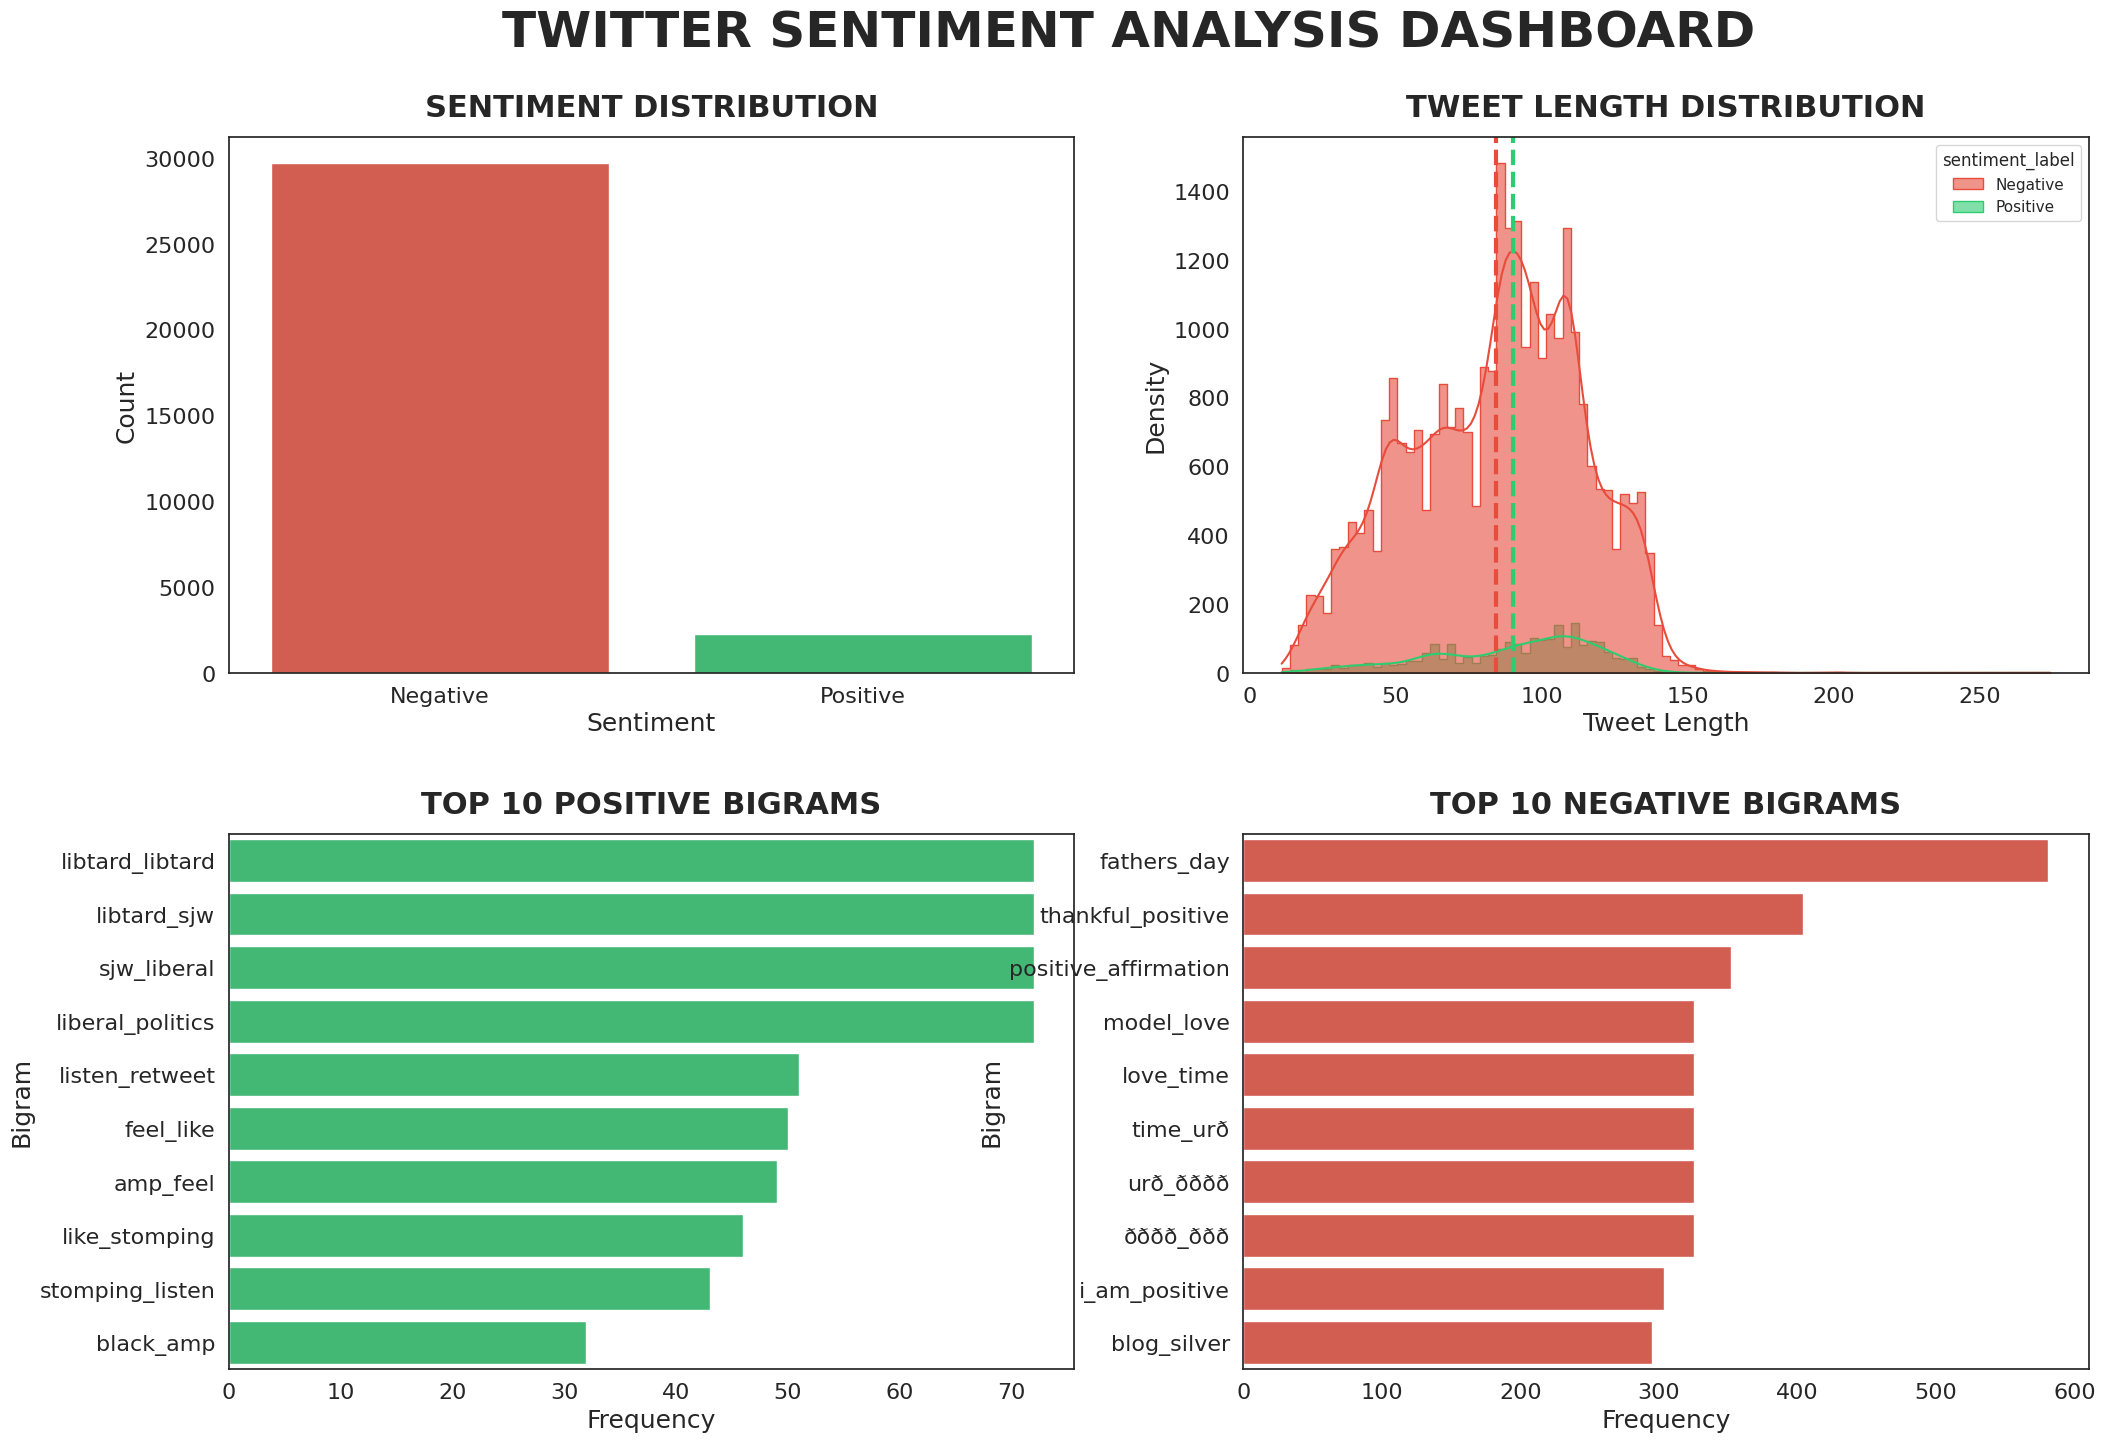

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from sklearn.feature_extraction.text import CountVectorizer

def load_data(url):
    try:
        df = pd.read_csv(url)
        return df
    except Exception as e:
        print(f"Error loading data: {e}")
        return None

def clean_text_advanced(text):
    if isinstance(text, str):
        text = re.sub(r"http\S+|www\S+|https\S+", '', text, flags=re.MULTILINE)
        text = re.sub(r'\@\w+|\#','', text)
        text = text.lower()
        text = re.sub(r'[^\w\s]', '', text)
        return text
    return ""

def preprocess_and_engineer_features(df):
    df_clean = df.copy()
    if 'label' in df_clean.columns:
        df_clean['sentiment_label'] = df_clean['label'].map({0: 'Negative', 1: 'Positive'})

    df_clean['cleaned_tweet'] = df_clean['tweet'].apply(clean_text_advanced)
    df_clean['tweet_length'] = df_clean['tweet'].apply(len)
    return df_clean

def extract_top_bigrams(df, sentiment, num=10):
    texts = df[df['sentiment_label'] == sentiment]['cleaned_tweet'].tolist()
    if not texts:
        return [], []

    vectorizer = CountVectorizer(ngram_range=(2, 2), stop_words='english')
    try:
        X = vectorizer.fit_transform(texts)
        sum_words = X.sum(axis=0)
        words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
        words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)[:num]
        return [w[0].replace(' ', '_') for w in words_freq], [w[1] for w in words_freq]
    except ValueError:
        return [], []

def generate_comprehensive_dashboard(df):
    sns.set_theme(style="white")
    fig, axes = plt.subplots(2, 2, figsize=(24, 16), gridspec_kw={'hspace': 0.3, 'wspace': 0.2})
    fig.suptitle('TWITTER SENTIMENT ANALYSIS DASHBOARD', fontsize=36, fontweight='bold', y=0.96)

    modern_palette = {'Negative': '#e74c3c', 'Positive': '#2ecc71'}

    sns.countplot(data=df, x='sentiment_label', hue='sentiment_label', palette=modern_palette, legend=False, ax=axes[0, 0])
    axes[0, 0].set_title('SENTIMENT DISTRIBUTION', fontsize=22, fontweight='bold', pad=15)
    axes[0, 0].set_xlabel('Sentiment', fontsize=18)
    axes[0, 0].set_ylabel('Count', fontsize=18)
    axes[0, 0].tick_params(axis='both', which='major', labelsize=16)

    sns.histplot(data=df, x='tweet_length', hue='sentiment_label', kde=True, palette=modern_palette, alpha=0.6, element='step', common_norm=False, ax=axes[0, 1])
    axes[0, 1].set_title('TWEET LENGTH DISTRIBUTION', fontsize=22, fontweight='bold', pad=15)
    axes[0, 1].set_xlabel('Tweet Length', fontsize=18)
    axes[0, 1].set_ylabel('Density', fontsize=18)
    axes[0, 1].tick_params(axis='both', which='major', labelsize=16)

    neg_mean = df[df['sentiment_label'] == 'Negative']['tweet_length'].mean()
    pos_mean = df[df['sentiment_label'] == 'Positive']['tweet_length'].mean()
    axes[0, 1].axvline(neg_mean, color='#e74c3c', linestyle='dashed', linewidth=3)
    axes[0, 1].axvline(pos_mean, color='#2ecc71', linestyle='dashed', linewidth=3)

    pos_bigrams, pos_counts = extract_top_bigrams(df, 'Positive', num=10)
    if pos_bigrams:
        sns.barplot(x=pos_counts, y=pos_bigrams, hue=pos_bigrams, palette=['#2ecc71']*len(pos_bigrams), legend=False, ax=axes[1, 0])
    axes[1, 0].set_title('TOP 10 POSITIVE BIGRAMS', fontsize=22, fontweight='bold', pad=15)
    axes[1, 0].set_xlabel('Frequency', fontsize=18)
    axes[1, 0].set_ylabel('Bigram', fontsize=18)
    axes[1, 0].tick_params(axis='both', which='major', labelsize=16)

    neg_bigrams, neg_counts = extract_top_bigrams(df, 'Negative', num=10)
    if neg_bigrams:
        sns.barplot(x=neg_counts, y=neg_bigrams, hue=neg_bigrams, palette=['#e74c3c']*len(neg_bigrams), legend=False, ax=axes[1, 1])
    axes[1, 1].set_title('TOP 10 NEGATIVE BIGRAMS', fontsize=22, fontweight='bold', pad=15)
    axes[1, 1].set_xlabel('Frequency', fontsize=18)
    axes[1, 1].set_ylabel('Bigram', fontsize=18)
    axes[1, 1].tick_params(axis='both', which='major', labelsize=16)

    plt.tight_layout()
    plt.show()

def main():
    url = 'https://raw.githubusercontent.com/dD2405/Twitter_Sentiment_Analysis/master/train.csv'
    df = load_data(url)
    if df is not None:
        processed_df = preprocess_and_engineer_features(df)
        generate_comprehensive_dashboard(processed_df)

if __name__ == "__main__":
    main()